In [77]:
import numpy as np
import pandas as pd
import yfinance as yf
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.trend import MACD, EMAIndicator, SMAIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator, MFIIndicator
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import random
from copy import deepcopy
import torch.nn.functional as F
import math

np.random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Data Preprocessing

In [156]:
# === 1) Download OHLCV for S&P 500 (adjusted), and context (VIX, 10Y yield) ===
start = "2010-01-01"
end = "2025-08-01"

px = yf.download("^GSPC", start=start, end=end, auto_adjust=True)
px = px.rename(columns=str.lower)[['open','high','low','close','volume']].dropna()
px.index.name = "date"

vix = (
    yf.download("^VIX", start=start, end=end, auto_adjust=True)
      .rename(columns=str.lower)[['close']]
      .rename(columns={'close': 'vix_close'})
)

tnx = (
    yf.download("^TNX", start=start, end=end, auto_adjust=True)
      .rename(columns=str.lower)[['close']]
      .rename(columns={'close': 'us10y_yield'})
)

ctx = vix.join(tnx, how="outer").sort_index().ffill()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [157]:
# === 2) Core return features (no leakage: all derived from t or earlier) ===
df = px.copy()
df['ret_1'] = df['close'].pct_change(1)
df['ret_5'] = df['close'].pct_change(5)
df['ret_10'] = df['close'].pct_change(10)
df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
df['ret_1_lag1'] = df['ret_1'].shift(1)
df['ret_1_lag2'] = df['ret_1'].shift(2)

In [159]:
def ensure_series(x, name=None):
    """Coerce a pandas object to a 1D float Series with the same index."""
    if isinstance(x, pd.DataFrame):
        x = x.iloc[:, 0]
    s = pd.Series(np.asarray(x).reshape(-1), index=x.index)
    if name is not None:
        s.name = name
    return s.astype(float)

In [160]:
# === 3) Rolling stats (trend/volatility/volume structure) ===
# Realised volatility on returns
for w in [5, 10, 20, 60]:
    df[f'sma_{w}'] = df['close'].rolling(w).mean()
    df[f'vol_{w}'] = df['ret_1'].rolling(w).std()

# Price z-score vs 20-day mean/std; return z-score too
close_s = ensure_series(df['close'], 'close') # Ensure Series, not DataFrames
sma20_s = ensure_series(df['sma_20'], 'sma_20')
std20_s = ensure_series(close.rolling(20).std(), 'std20')

df['close_z_20'] = (close_s - sma20_s) / (std20_s + 1e-8)
df['ret_z_20'] = (df['ret_1'] - df['ret_1'].rolling(20).mean()) / (df['ret_1'].rolling(20).std() + 1e-8)

# Rolling volume signals
for w in [5, 20, 60]:
    df[f'volu_mean_{w}'] = df['volume'].rolling(w).mean()

volume_s = ensure_series(df['volume'], 'volume')
volm5_s = ensure_series(df['volu_mean_5'], 'volu_mean_5')
volm20_s = ensure_series(df['volu_mean_20'], 'volu_mean_20')
volm60_s = ensure_series(df['volu_mean_60'], 'volu_mean_60')

df['volu_ratio_5'] = volume_s / (volm5_s + 1e-8)
df['volu_ratio_20'] = volume_s / (volm20_s + 1e-8)
df['volu_ratio_60'] = volume_s / (volm60_s + 1e-8)

In [162]:
# === 4) Technical indicators (common in practice) ===
high_s = ensure_series(df['high'], 'high')
low_s = ensure_series(df['low'], 'low')
vol_s = ensure_series(df['volume'], 'volume')

# RSI(14)
df['rsi_14'] = RSIIndicator(close=close_s, window=14).rsi()

# MACD (12,26,9)
macd = MACD(close=close_s, window_slow=26, window_fast=12, window_sign=9)
df['macd'] = macd.macd()
df['macd_signal'] = macd.macd_signal()
df['macd_diff'] = macd.macd_diff()

# Bollinger Bands (20, 2)
bb = BollingerBands(close=close_s, window=20, window_dev=2)
df['bb_high'] = bb.bollinger_hband()
df['bb_low'] = bb.bollinger_lband()
df['bb_pct'] = (close_s - df['bb_low']) / (df['bb_high'] - df['bb_low'] + 1e-8)

# EMAs / SMAs
for w in [10, 20, 50, 100, 200]:
    df[f'ema_{w}'] = EMAIndicator(close=close_s, window=w).ema_indicator()
    df[f'sma_{w}'] = SMAIndicator(close=close_s, window=w).sma_indicator()

# ATR(14) (range/volatility)
df['atr_14'] = AverageTrueRange(high=high_s, low=low_s, close=close_s, window=14).average_true_range()

# OBV (volume trend)
df['obv'] = OnBalanceVolumeIndicator(close=close_s, volume=vol_s).on_balance_volume()

# Stochastic Oscillator (14,3)
stoch = StochasticOscillator(high=high_s, low=low_s, close=close_s, window=14, smooth_window=3)
df['stoch_k'] = stoch.stoch()
df['stoch_d'] = stoch.stoch_signal()

# MFI(14)
df['mfi_14'] = MFIIndicator(high=high_s, low=low_s, close=close_s, volume=vol_s, window=14).money_flow_index()

In [164]:
# === 5) Calendar (day-of-week cyclic encoding) ===
df['dow'] = pd.Index(df.index).dayofweek  # 0=Mon
df['dow_sin'] = np.sin(2 * np.pi * df['dow'] / 5.0)
df['dow_cos'] = np.cos(2 * np.pi * df['dow'] / 5.0)
df = df.drop(columns=['dow'])

/var/folders/5b/m__nztsd5nl5h84q5f2pnr6h0000gn/T/ipykernel_96843/3781944526.py:5: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['dow'])


In [165]:
# === 6) Merge context (VIX, 10Y yield), forward-fill ===
df = df.join(ctx, how="left").ffill()

In [166]:
# === 7) Define target: next-day return (leakage-safe) ===
df['target'] = df['ret_1'].shift(-1)

# Drop warm-up NA rows from indicators and the last row from target shift
df = df.dropna().copy()

In [167]:
df

Price,open,high,low,close,volume,ret_1,ret_5,ret_10,log_ret,ret_1_lag1,...,atr_14,obv,stoch_k,stoch_d,mfi_14,dow_sin,dow_cos,vix_close,us10y_yield,target
Ticker,^gspc,^gspc,^gspc,^gspc,^gspc,,,,,,...,,,,,,,,^vix,^tnx,
date,,,,,,,,,,,,,,,,,,,,,
2010-10-18,1176.829956,1185.530029,1174.550049,1184.709961,4450050000,0.007244,0.016639,0.041934,0.007218,0.002027,...,13.795537,6.144474e+10,98.471733,87.581731,78.821819,0.000000,1.000000,19.090000,2.491,-0.015877
2010-10-19,1178.640015,1178.640015,1159.709961,1165.900024,5600120000,-0.015877,-0.003308,0.004437,-0.016005,0.007244,...,14.595856,5.584462e+10,63.417830,82.097472,70.107160,0.951057,0.309017,20.629999,2.475,0.010524
2010-10-20,1166.739990,1182.939941,1166.739990,1178.170044,5027880000,0.010524,0.000059,0.015690,0.010469,-0.015877,...,14.770431,6.087250e+10,86.284046,82.724537,70.529923,0.587785,-0.809017,19.790001,2.470,0.001774
2010-10-21,1179.819946,1189.430054,1171.170044,1180.260010,4625470000,0.001774,0.005495,0.019170,0.001772,0.010524,...,15.019687,6.549797e+10,84.068738,77.923538,70.749797,-0.587785,-0.809017,19.270000,2.531,0.002389
2010-10-22,1180.520020,1183.930054,1178.989990,1183.079956,3177890000,0.002389,0.005858,0.015389,0.002386,0.001774,...,14.299714,6.867586e+10,86.974159,85.775648,76.351766,-0.951057,0.309017,18.780001,2.563,0.002147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-24,6368.600098,6381.310059,6360.569824,6363.350098,5282720000,0.000698,0.010479,0.013198,0.000698,0.007812,...,48.568461,1.187828e+12,90.039402,90.350658,63.972585,-0.587785,-0.809017,15.390000,4.408,0.003974
2025-07-25,6370.009766,6395.819824,6368.529785,6388.640137,4470720000,0.003974,0.014587,0.020590,0.003966,0.000698,...,47.418552,1.192298e+12,96.303512,95.086413,70.815302,-0.951057,0.309017,14.930000,4.386,0.000177


In [168]:
# === 8) Select a practitioner-style feature set ===
feature_cols = [
    # price & volume & returns
    'close','volume','ret_1','ret_5','ret_10','log_ret','ret_1_lag1','ret_1_lag2',
    # trend & volatility
    'sma_10','sma_20','sma_50','sma_100','sma_200',
    'ema_10','ema_20','ema_50','ema_100','ema_200',
    'vol_5','vol_10','vol_20','vol_60','close_z_20','ret_z_20',
    # bands & oscillators
    'bb_high','bb_low','bb_pct','rsi_14','stoch_k','stoch_d','mfi_14',
    # momentum (MACD)
    'macd','macd_signal','macd_diff',
    # range & volume flow
    'atr_14','obv',
    # calendar
    'dow_sin','dow_cos',
    # context
    'vix_close','us10y_yield'
]

In [169]:
# === 9) Build LSTM sequences (lookback window) ===
WINDOW = 60  # days lookback
X_list, y_list, idx_list = [], [], []
for i in range(WINDOW, len(df)):
    X_list.append(df[feature_cols].iloc[i-WINDOW:i].values) # shape (WINDOW, n_features)
    y_list.append(df['target'].iloc[i]) # scalar next-day return
    idx_list.append(df.index[i]) # time index of target

X = np.array(X_list, dtype=np.float32) # (N, WINDOW, n_features)
y = np.array(y_list, dtype=np.float32).reshape(-1, 1) # (N, 1)
idx = pd.Index(idx_list, name="date")

print(f"Raw sequences -> X: {X.shape}, y: {y.shape}")

Raw sequences -> X: (3658, 60, 40), y: (3658, 1)


In [170]:
# === 10) Time-ordered split (no shuffle) ===
split_ratio = 0.8
split_point = int(len(X) * split_ratio)

X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]
idx_train, idx_test = idx[:split_point], idx[split_point:]

In [171]:
# === 11) Scale features using TRAIN-only stats (target left unscaled for returns) ===
scaler = StandardScaler(with_mean=True, with_std=True)

n_train, seq_len, n_feat = X_train.shape
X_train_2d = X_train.reshape(-1, n_feat)
X_test_2d = X_test.reshape(-1, n_feat)

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(n_train, seq_len, n_feat)
X_test_scaled = scaler.transform(X_test_2d).reshape(X_test.shape[0], seq_len, n_feat)

y_scaler = StandardScaler(with_mean=True, with_std=True)
y_train_scaled = y_scaler.fit_transform(y_train)

In [172]:
# === 12) To PyTorch tensors and DataLoaders ===
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, drop_last=False)

print("DataLoaders ready.")
print(f"Feature count: {len(feature_cols)}")

DataLoaders ready.
Feature count: 40


## Baseline LSTM

In [173]:
# Define LSTM Model
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3):
        super(LSTMRegressor, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_out = out[:, -1, :]
        return self.fc(last_out)

# Training Loop
def train_model(model, train_loader, num_epochs=50, lr=1e-3):
    criterion = nn.MSELoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimiser.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(train_loader):.6f}")

In [174]:
def evaluate_model(model, test_loader):
    model.eval()
    predictions, actuals = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_pred = model(X_batch)
            predictions.extend(y_pred.squeeze().tolist())
            actuals.extend(y_batch.squeeze().tolist())
    return predictions, actuals

# Train and Evaluate
input_size = X_train_scaled.shape[2]
model = LSTMRegressor(input_size=input_size)
train_model(model, train_loader)

preds, trues = evaluate_model(model, test_loader)

Epoch 10/50, Loss: 0.975047
Epoch 20/50, Loss: 0.769755
Epoch 30/50, Loss: 0.402025
Epoch 40/50, Loss: 0.198608
Epoch 50/50, Loss: 0.092348


In [178]:
# Inverse transform to get real price
preds_unscaled = y_scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

# Compute metrics
rmse = root_mean_squared_error(y_test, preds_unscaled)
mae = mean_absolute_error(y_test, preds_unscaled)

print(f"Baseline LSTM — RMSE: {rmse:.6f} | MAE: {mae:.6f}")

Baseline LSTM — RMSE: 0.014581 | MAE: 0.010707


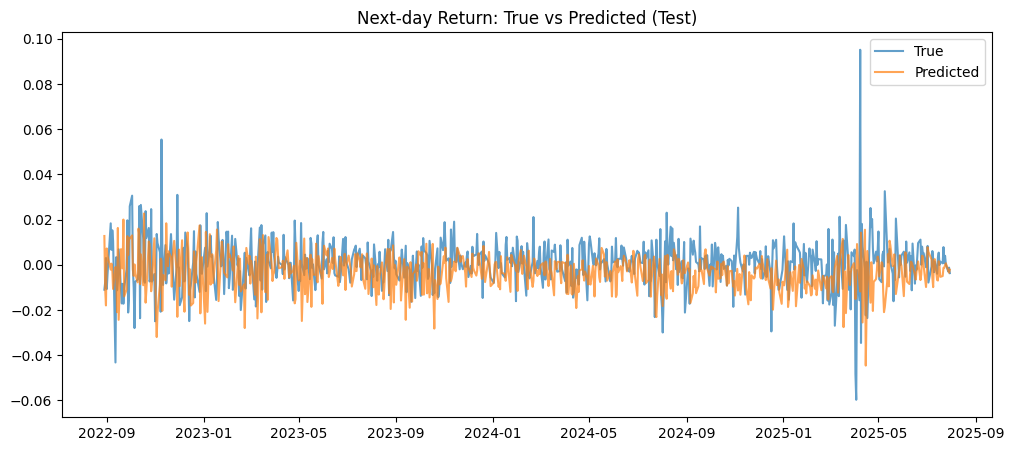

In [179]:
plt.figure(figsize=(12, 5))
plt.plot(idx_test, y_test, label="True", alpha=0.7)
plt.plot(idx_test, preds_unscaled, label="Predicted", alpha=0.7)
plt.title("Next-day Return: True vs Predicted (Test)")
plt.legend()
plt.show()

## MC Dropout

In [180]:
# Define MC Dropout Model
class MCDropoutLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3, dropout=0.5):
        super(MCDropoutLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])  # Dropout on last output
        return self.fc(out)

In [181]:
# Train and Evaluate
input_size = X_train_scaled.shape[2]
mc_model = MCDropoutLSTM(input_size=input_size)
train_model(mc_model, train_loader)

Epoch 10/50, Loss: 0.993277
Epoch 20/50, Loss: 0.959137
Epoch 30/50, Loss: 0.851442
Epoch 40/50, Loss: 0.699462
Epoch 50/50, Loss: 0.562669


In [182]:
def predict_mc_dropout(model, X_tensor, T=50):
    model.eval()
    predictions = []

    # Enable dropout
    def enable_dropout(m):
        if isinstance(m, nn.Dropout):
            m.train()

    model.apply(enable_dropout)

    with torch.no_grad():
        for _ in range(T):
            preds = model(X_tensor).squeeze().cpu().numpy()
            predictions.append(preds)

    predictions = np.array(predictions)  # shape: (T, N)
    pred_mean = predictions.mean(axis=0)
    pred_std = predictions.std(axis=0)
    return pred_mean, pred_std

mc_mean, mc_std = predict_mc_dropout(mc_model, X_test_tensor, T=50)

In [183]:
# PICP: Proportion of true values that fall within the prediction interval
def picp(mean, std, trues):
    z = 1.96  # for 95% CI under Gaussian assumption
    lower = mean - z * std
    upper = mean + z * std

    within_interval = (trues >= lower) & (trues <= upper)
    
    return np.mean(within_interval)

# MPIW: Average width of the prediction interval
def mpiw(mean, std):
    z = 1.96  # for 95% CI under Gaussian assumption
    lower = mean - z * std
    upper = mean + z * std
    
    return np.mean(upper - lower)

In [184]:
# Inverse transform to get real price
mc_mean_unscaled = y_scaler.inverse_transform(np.array(mc_mean).reshape(-1, 1)).flatten()
mc_std_unscaled = y_scaler.inverse_transform(np.array(mc_std).reshape(-1, 1)).flatten()
h the baselineference:

mc_rmse = root_mean_squared_error(y_test, mc_mean_unscaled)
mc_mae = mean_absolute_error(y_test, mc_mean_unscaled)
mc_picp = picp(mc_mean_unscaled, mc_std_unscaled, y_test)
mc_mpiw = mpiw(mc_mean_unscaled, mc_std_unscaled)

print(f"MC Dropout RMSE: {mc_rmse:.6f}")
print(f"MC Dropout MAE: {mc_mae:.6f}")
print(f"MC Dropout PICP (95%): {mc_picp:.6f}")
print(f"MC Dropout MPIW: {mc_mpiw:.6f}")

MC Dropout RMSE: 0.013568
MC Dropout MAE: 0.010519
MC Dropout PICP (95%): 0.174281
MC Dropout MPIW: 0.006792


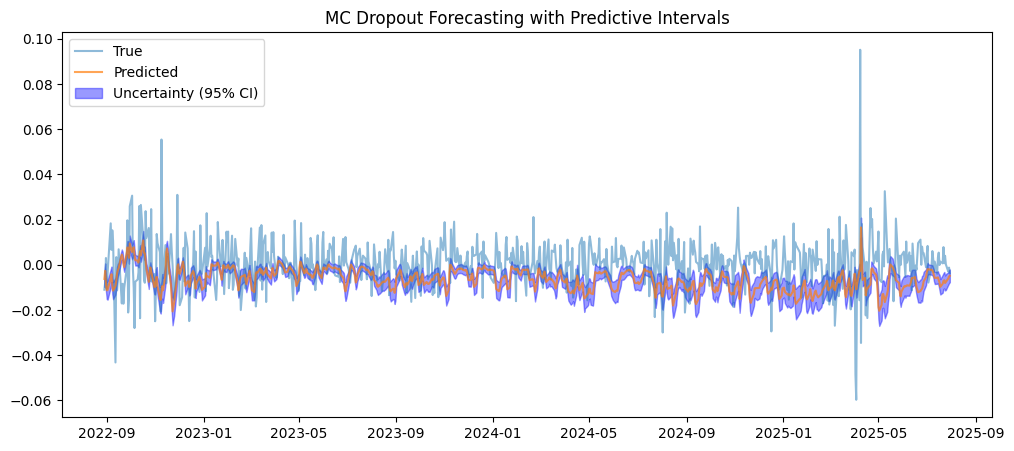

In [185]:
mc_lower = mc_mean_unscaled - 1.96 * mc_std_unscaled
mc_upper = mc_mean_unscaled + 1.96 * mc_std_unscaled

plt.figure(figsize=(12, 5))
plt.plot(idx_test, y_test, label="True", alpha=0.5)
plt.plot(idx_test, mc_mean_unscaled, label="Predicted", alpha=0.7)
plt.fill_between(idx_test, mc_lower, mc_upper, alpha=0.4, label='Uncertainty (95% CI)', color='blue')
plt.title("MC Dropout Forecasting with Predictive Intervals")
plt.legend()
plt.show()

In [186]:
# Split test into calib + final (time-ordered)
n_test = len(y_test)
n_cal  = int(0.4 * n_test)  # 40% for calibration; adjust as you like

X_cal_tensor = X_test_tensor[:n_cal]
X_fin_tensor = X_test_tensor[n_cal:]
y_cal_real = np.asarray(y_test[:n_cal]).astype(float).ravel()
y_fin_real = np.asarray(y_test[n_cal:]).astype(float).ravel()

# Conformal (absolute residual quantile) on calibration
mc_mu_cal, mc_sd_cal = predict_mc_dropout(mc_model, X_cal_tensor, T=50)

mc_mu_cal_real = y_scaler.inverse_transform(np.array(mc_mu_cal).reshape(-1,1)).ravel()
mc_resid = np.abs(y_cal - mc_mu_cal_real)
mc_q = np.quantile(mc_resid, 0.95)

# Apply to final
mc_mu_fin, mc_sd_fin = predict_mc_dropout(mc_model, X_fin_tensor, T=50)
mc_mu_fin_real = y_scaler.inverse_transform(np.array(mc_mu_fin).reshape(-1,1)).ravel()
mc_lower_c = mc_mu_fin_real - mc_q
mc_upper_c = mc_mu_fin_real + mc_q

mc_picp_c = np.mean((y_test[n_cal:] >= mc_lower_c) & (y_test[n_cal:] <= mc_upper_c))
mc_mpiw_c = np.mean(mc_upper_c - mc_lower_c)
print(f"Conformal MC — PICP: {mc_picp_c:.6f} | MPIW: {mc_mpiw_c:.6f}")

Conformal MC — PICP: 0.948497 | MPIW: 0.049279


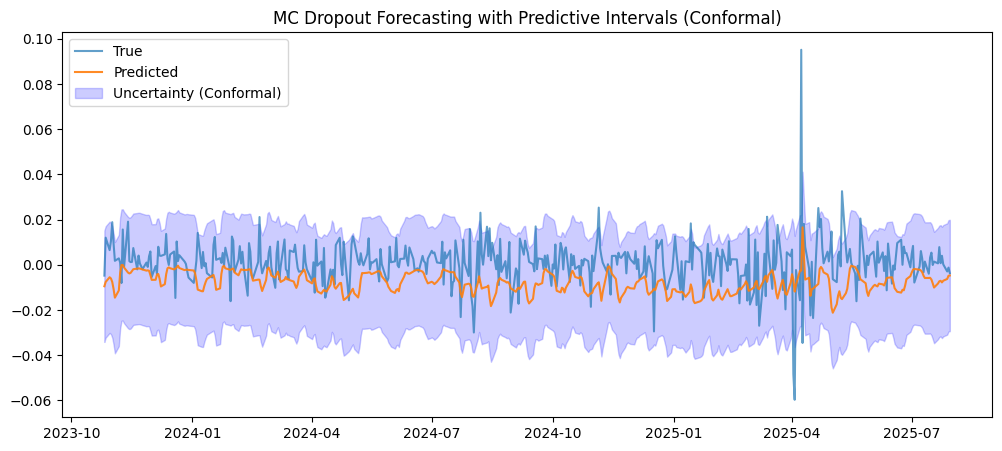

In [190]:
idx_fin = idx_test[n_cal:]

plt.figure(figsize=(12, 5))
plt.plot(idx_fin, y_test[n_cal:], label="True", alpha=0.7)
plt.plot(idx_fin, mu_fin_unscaled, label="Predicted", alpha=0.9)
plt.fill_between(idx_fin, lower_c, upper_c, alpha=0.2, label='Uncertainty (Conformal)', color='blue')
plt.title("MC Dropout Forecasting with Predictive Intervals (Conformal)")
plt.legend()
plt.show()

In [244]:
# Std rescales linearly by the same factor used for y standardisation
y_std = float(getattr(y_scaler, "scale_", [1.0])[0])
mc_sd_cal_real = mc_sd_cal * y_std
mc_sd_fin_real = mc_sd_fin * y_std

# --- Normalised residuals on calibration slice ---
eps = 1e-12
mc_norm_resid = np.abs(y_cal_real - mc_mu_cal_real) / (mc_sd_cal_real + eps)

# Finite-sample conservative correction
alpha = 0.2
k = int(np.ceil((n_cal + 1) * (1 - alpha)))  # order statistic index
mc_q_norm = np.sort(mc_norm_resid)[min(k-1, len(mc_norm_resid)-1)]  # guard bounds

# --- Adaptive (heteroscedastic) conformal intervals on final slice ---
mc_lower_h = mc_mu_fin_real - mc_q_norm * mc_sd_fin_real
mc_upper_h = mc_mu_fin_real + mc_q_norm * mc_sd_fin_real

mc_picp_h  = np.mean((y_fin_real >= mc_lower_h) & (y_fin_real <= mc_upper_h))
mc_mpiw_h  = np.mean(mc_upper_h - mc_lower_h)

print(f"Hybrid (normalised conformal) — PICP: {mc_picp_h:.6f} | MPIW: {mc_mpiw_h:.6f}")

Hybrid (normalised conformal) — PICP: 0.938636 | MPIW: 0.052238


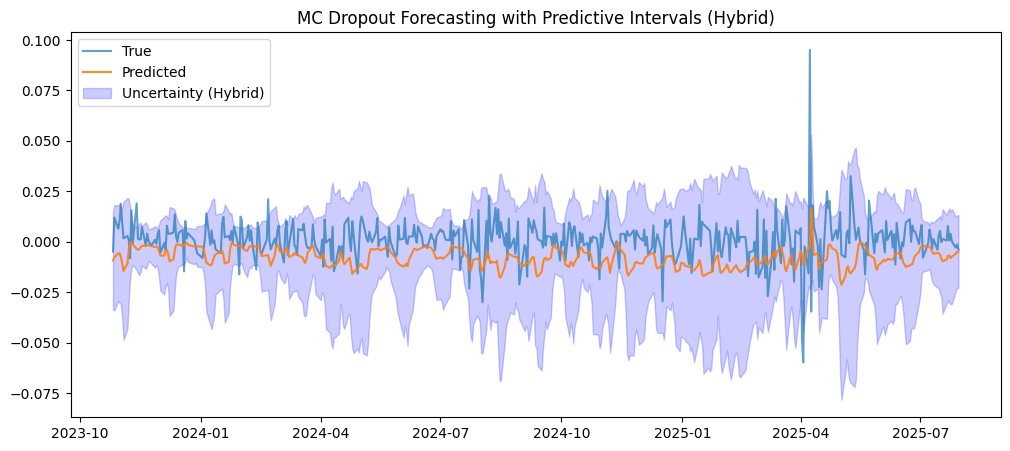

In [245]:
plt.figure(figsize=(12, 5))
plt.plot(idx_fin, y_test[n_cal:], label="True", alpha=0.7)
plt.plot(idx_fin, mu_fin_real, label="Predicted", alpha=0.9)
plt.fill_between(idx_fin, lower_h, upper_h, alpha=0.2, label='Uncertainty (Hybrid)', color='blue')
plt.title("MC Dropout Forecasting with Predictive Intervals (Hybrid)")
plt.legend()
plt.show()

## Deep Ensembles

In [246]:
class EnsembleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.fc(last)

In [248]:
def train_single_model(model, train_loader, epochs=50, lr=1e-3, device="cpu", seed=None):
    if seed is not None:
        torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    model.to(device)
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        epoch_loss = 0
        for xb, yb in train_loader:
            xb = xb.to(device); yb = yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.6f}")

def train_ensemble(n_members, input_size, train_loader, hidden_size=128, num_layers=3, dropout=0.0, epochs=50, lr=1e-3, 
                   device="cpu", base_seed=42):
    members = []
    for m in range(n_members):
        seed = base_seed + m
        model = EnsembleLSTM(input_size, hidden_size, num_layers, dropout)
        print(f"Ensemble {m}:")
        train_single_model(model, train_loader, epochs=epochs, lr=lr, device=device, seed=seed)
        members.append(deepcopy(model).cpu())  # keep on CPU for prediction
    return members

In [250]:
n_members = 5
input_size = X_train_scaled.shape[2]

ensemble_models = train_ensemble(
    n_members=n_members,
    input_size=input_size,
    train_loader=train_loader,
    hidden_size=128,
    num_layers=3,
    dropout=0.0,          # keep dropout off for deep ensemble
    epochs=70,
    lr=1e-3,
    device="cpu",
    base_seed=7
)

Ensemble 0:
Epoch 10/70, Loss: 0.954170
Epoch 20/70, Loss: 0.700471
Epoch 30/70, Loss: 0.406995
Epoch 40/70, Loss: 0.149242
Epoch 50/70, Loss: 0.048328
Epoch 60/70, Loss: 0.019191
Epoch 70/70, Loss: 0.011794
Ensemble 1:
Epoch 10/70, Loss: 0.964852
Epoch 20/70, Loss: 0.643960
Epoch 30/70, Loss: 0.287966
Epoch 40/70, Loss: 0.111701
Epoch 50/70, Loss: 0.046566
Epoch 60/70, Loss: 0.016938
Epoch 70/70, Loss: 0.014988
Ensemble 2:
Epoch 10/70, Loss: 0.970628
Epoch 20/70, Loss: 0.692213
Epoch 30/70, Loss: 0.372429
Epoch 40/70, Loss: 0.156412
Epoch 50/70, Loss: 0.069267
Epoch 60/70, Loss: 0.030176
Epoch 70/70, Loss: 0.014764
Ensemble 3:
Epoch 10/70, Loss: 0.984503
Epoch 20/70, Loss: 0.801635
Epoch 30/70, Loss: 0.431879
Epoch 40/70, Loss: 0.191799
Epoch 50/70, Loss: 0.079976
Epoch 60/70, Loss: 0.037181
Epoch 70/70, Loss: 0.022370
Ensemble 4:
Epoch 10/70, Loss: 0.968467
Epoch 20/70, Loss: 0.702841
Epoch 30/70, Loss: 0.382134
Epoch 40/70, Loss: 0.156216
Epoch 50/70, Loss: 0.065012
Epoch 60/70, Los

In [251]:
@torch.no_grad()
def predict_ensemble(members, X_tensor, device="cpu"):
    preds = []
    for model in members:
        model.eval()
        model.to(device)
        out = model(X_tensor.to(device)).squeeze(1).cpu().numpy()  # shape (N,)
        preds.append(out)
    preds = np.stack(preds, axis=0)  # (M, N)
    mean_pred = preds.mean(axis=0)   # (N,)
    std_pred = preds.std(axis=0)     # (N,)
    return mean_pred, std_pred, preds

ens_mean, ens_std, _ = predict_ensemble(ensemble_models, X_test_tensor, device=device)

In [252]:
ens_mean_unscaled = y_scaler.inverse_transform(np.array(ens_mean).reshape(-1, 1)).flatten()
ens_std_unscaled = y_scaler.inverse_transform(np.array(ens_std).reshape(-1, 1)).flatten()

ens_rmse = root_mean_squared_error(y_test, ens_mean_unscaled)
ens_mae = mean_absolute_error(y_test, ens_mean_unscaled)
ens_picp = picp(ens_mean_unscaled, ens_std_unscaled, y_test)
ens_mpiw = mpiw(ens_mean_unscaled, ens_std_unscaled)

print(f"Deep Ensemble (M={n_members})")
print(f"RMSE: {ens_rmse:.4f}")
print(f"MAE:  {ens_mae:.4f}")
print(f"PICP (95%): {ens_picp:.4f}")
print(f"MPIW: {ens_mpiw:.4f}")

Deep Ensemble (M=5)
RMSE: 0.0132
MAE:  0.0096
PICP (95%): 0.6301
MPIW: 0.0220


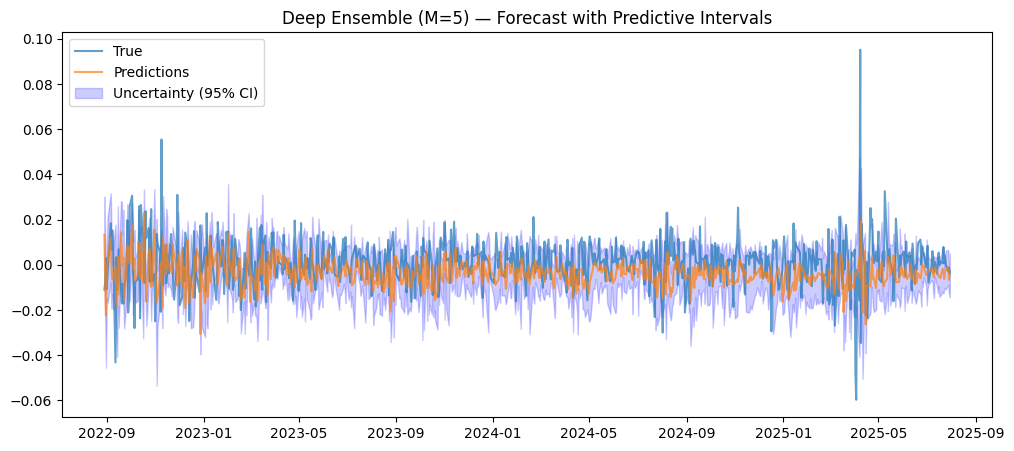

In [255]:
ens_lower = ens_mean_unscaled - 1.96 * ens_std_unscaled
ens_upper = ens_mean_unscaled + 1.96 * ens_std_unscaled

plt.figure(figsize=(12, 5))
plt.plot(idx_test, y_test, label="True", alpha=0.7)
plt.plot(idx_test, ens_mean_unscaled, label="Predicted", alpha=0.7)
plt.fill_between(idx_test, ens_lower, ens_upper, alpha=0.2, label='Uncertainty (95% CI)', color='blue')
plt.title(f"Deep Ensemble (M={n_members}) — Forecast with Predictive Intervals")
plt.legend()
plt.show()

In [266]:
# --- Split test into calibration + final (time-ordered) ---
n_test = len(y_test)
n_cal  = int(0.4 * n_test) # 40% for calibration; adjust as you like

X_cal_tensor = X_test_tensor[:n_cal]
X_fin_tensor = X_test_tensor[n_cal:]
y_cal_real = np.asarray(y_test[:n_cal]).astype(float).ravel()
y_fin_real = np.asarray(y_test[n_cal:]).astype(float).ravel()

# Conformal (absolute residual quantile) on calibration & final
ens_mu_cal, ens_sd_cal, _ = predict_ensemble(ensemble_models, X_cal_tensor, device=device)
ens_mu_fin, ens_sd_fin, _ = predict_ensemble(ensemble_models, X_fin_tensor, device=device)

# Invert both mean & std to REAL scale
ens_mu_cal_real = y_scaler.inverse_transform(np.array(ens_mu_cal).reshape(-1,1)).ravel()
ens_mu_fin_real = y_scaler.inverse_transform(np.array(ens_mu_fin).reshape(-1,1)).ravel()

ens_resid = np.abs(y_cal_real - ens_mu_cal_real)
ens_q = np.quantile(ens_resid, 0.95)
ens_lower_c = ens_mu_fin_real - ens_q
ens_upper_c = ens_mu_fin_real + ens_q

ens_picp_c = np.mean((y_fin_real >= ens_lower_c) & (y_fin_real <= ens_upper_c))
ens_mpiw_c = np.mean(ens_upper_c - ens_lower_c)
print(f"Conformal MC — PICP: {ens_picp_c:.6f} | MPIW: {ens_mpiw_c:.6f}")

Conformal MC — PICP: 0.965909 | MPIW: 0.055400


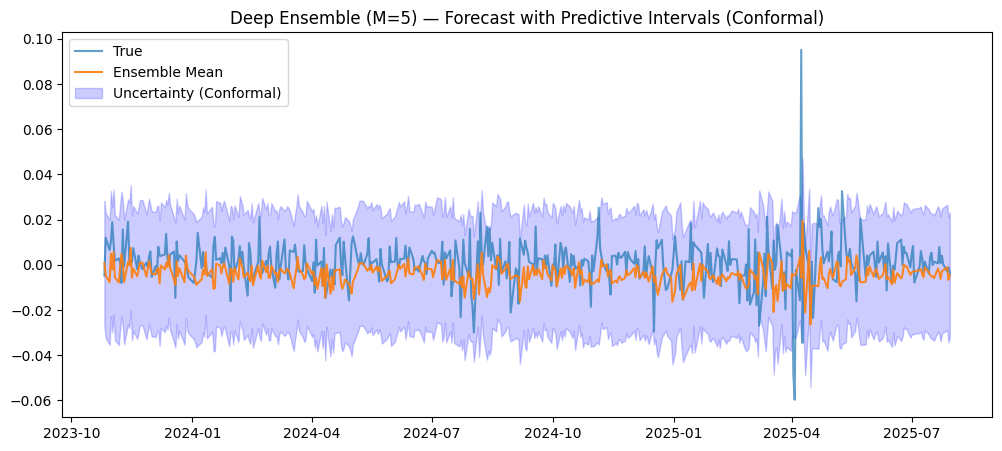

In [267]:
idx_fin = idx_test[n_cal:]

plt.figure(figsize=(12, 5))
plt.plot(idx_fin, y_test[n_cal:], label="True", alpha=0.7)
plt.plot(idx_fin, ens_mu_fin_real, label="Predicted", alpha=0.9)
plt.fill_between(idx_fin, ens_lower_c, ens_upper_c, alpha=0.2, label='Uncertainty (Conformal)', color='blue')
plt.title(f"Deep Ensemble (M={n_members}) — Forecast with Predictive Intervals (Conformal)")
plt.legend()
plt.show()

In [258]:
# Std rescales linearly by the same factor used for y standardisation
y_std = float(getattr(y_scaler, "scale_", [1.0])[0])
ens_sd_cal_real = ens_sd_cal * y_std
ens_sd_fin_real = ens_sd_fin * y_std

# --- Normalised residuals on calibration slice ---
eps = 1e-12
ens_norm_resid = np.abs(y_cal_real - ens_mu_cal_real) / (ens_sd_cal_real + eps)

# Finite-sample conservative correction
alpha = 0.2
k = int(np.ceil((n_cal + 1) * (1 - alpha)))  # order statistic index
ens_q_norm = np.sort(ens_norm_resid)[min(k-1, len(ens_norm_resid)-1)]  # guard bounds

# --- Adaptive (heteroscedastic) conformal intervals on final slice ---
ens_lower_h = ens_mu_fin_real - ens_q_norm * ens_sd_fin_real
ens_upper_h = ens_mu_fin_real + ens_q_norm * ens_sd_fin_real

ens_picp_h = np.mean((y_fin_real >= ens_lower_h) & (y_fin_real <= ens_upper_h))
ens_mpiw_h = np.mean(ens_upper_h - ens_lower_h)

print(f"Hybrid (normalised conformal) — PICP: {ens_picp_h:.6f} | MPIW: {ens_mpiw_h:.6f}")

Hybrid (normalised conformal) — PICP: 0.863636 | MPIW: 0.038615


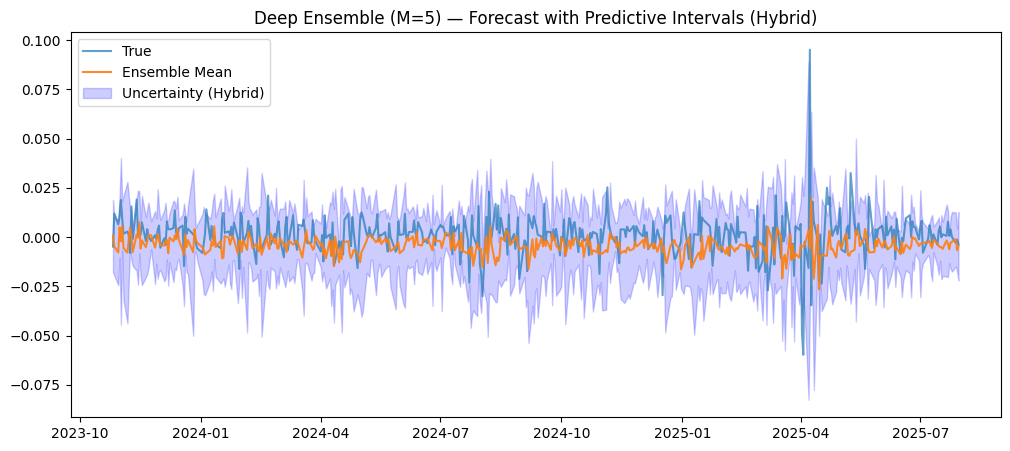

In [259]:
plt.figure(figsize=(12, 5))
plt.plot(idx_fin, y_test[n_cal:], label="True", alpha=0.7)
plt.plot(idx_fin, ens_mu_fin_real, label="Predicted", alpha=0.9)
plt.fill_between(idx_fin, ens_lower_h, ens_upper_h, alpha=0.2, label='Uncertainty (Hybrid)', color='blue')
plt.title(f"Deep Ensemble (M={n_members}) — Forecast with Predictive Intervals (Hybrid)")
plt.legend()
plt.show()

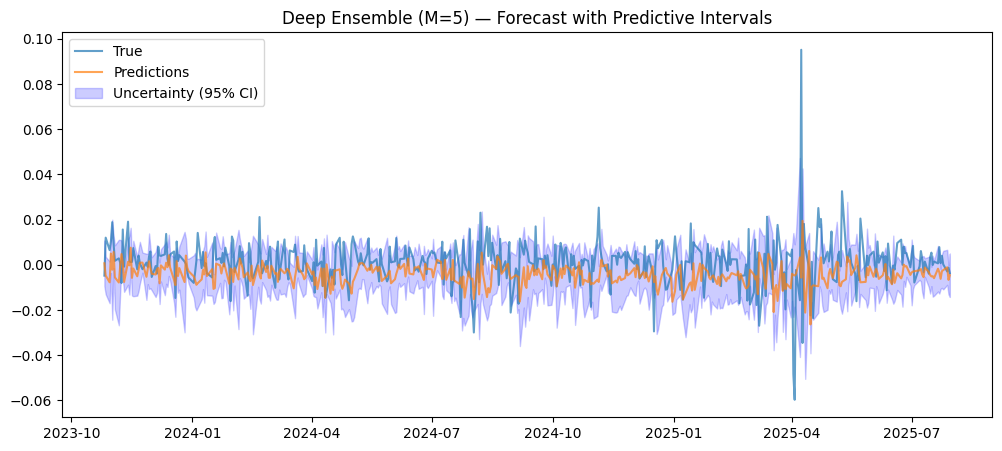

In [260]:
plt.figure(figsize=(12, 5))
plt.plot(idx_fin, y_test[n_cal:], label="True", alpha=0.7)
plt.plot(idx_fin, ens_mean_unscaled[n_cal:], label="Predictions", alpha=0.7)
plt.fill_between(idx_fin, ens_lower[n_cal:], ens_upper[n_cal:], alpha=0.2, label='Uncertainty (95% CI)', color='blue')
plt.title(f"Deep Ensemble (M={n_members}) — Forecast with Predictive Intervals")
plt.legend()
plt.show()

## Bayes by Backprop

In [261]:
# ---- Bayesian Linear layer (mean-field Gaussian) ----
class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_sigma=1.0):
        super().__init__()
        # Variational parameters
        self.weight_mu = nn.Parameter(torch.Tensor(out_features, in_features).uniform_(-0.1, 0.1))
        self.weight_logvar = nn.Parameter(torch.Tensor(out_features, in_features).uniform_(-5.0, -4.0))
        self.bias_mu = nn.Parameter(torch.Tensor(out_features).uniform_(-0.1, 0.1))
        self.bias_logvar = nn.Parameter(torch.Tensor(out_features).uniform_(-5.0, -4.0))
        # Prior (zero-mean isotropic Gaussian)
        self.prior_sigma = prior_sigma
        self.prior_var = prior_sigma ** 2

    def forward(self, x):
        # Reparameterisation: w = mu + sigma * eps
        weight_sigma = torch.exp(0.5 * self.weight_logvar)
        bias_sigma   = torch.exp(0.5 * self.bias_logvar)
        w = self.weight_mu + weight_sigma * torch.randn_like(self.weight_mu)
        b = self.bias_mu   + bias_sigma   * torch.randn_like(self.bias_mu)
        return F.linear(x, w, b)

    def kl(self):
        # KL(q(w|θ) || p(w)), closed-form for diagonal Gaussians
        # sum over weights and biases
        weight_kl = 0.5 * torch.sum(
            (torch.exp(self.weight_logvar) + self.weight_mu**2) / self.prior_var
            - 1.0 - self.weight_logvar + math.log(self.prior_var)
        )
        bias_kl = 0.5 * torch.sum(
            (torch.exp(self.bias_logvar) + self.bias_mu**2) / self.prior_var
            - 1.0 - self.bias_logvar + math.log(self.prior_var)
        )
        return weight_kl + bias_kl

In [262]:
# ---- BBB-LSTM: deterministic LSTM encoder + Bayesian linear head ----
class BBB_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3, prior_sigma=1.0):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.head = BayesianLinear(hidden_size, 1, prior_sigma=prior_sigma)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.head(last)

    def kl(self):
        return self.head.kl()

In [263]:
def train_bbb(model, train_loader, epochs=60, lr=1e-3, device="cpu", kl_scale_strategy="linear", prior_sigma=1.0):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    n_batches_per_epoch = len(train_loader)

    def kl_weight(epoch_idx, batch_idx):
        # Anneal KL from 0 -> 1 across training for stability
        if kl_scale_strategy == "linear":
            total_steps = epochs * n_batches_per_epoch
            step = epoch_idx * n_batches_per_epoch + batch_idx + 1
            return min(1.0, step / total_steps)
        else:
            return 1.0

    for epoch in range(epochs):
        model.train()
        running = 0.0
        for bidx, (xb, yb) in enumerate(train_loader):
            xb = xb.to(device); yb = yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            data_loss = mse(pred, yb)
            kl = model.kl()
            beta = kl_weight(epoch, bidx)
            loss = data_loss + beta * kl / xb.shape[0]  # normalise KL by batch size
            loss.backward()
            opt.step()
            running += loss.item()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {running/len(train_loader):.6f}")

In [264]:
# === Train ===
bbb_model = BBB_LSTM(input_size=X_train_scaled.shape[2], hidden_size=128, num_layers=3, prior_sigma=1.0)
train_bbb(bbb_model, train_loader, epochs=80, lr=1e-3, device="cpu", kl_scale_strategy="linear")

Epoch 10/80 | Loss: 1.426369
Epoch 20/80 | Loss: 1.709652
Epoch 30/80 | Loss: 1.685979
Epoch 40/80 | Loss: 1.421218
Epoch 50/80 | Loss: 1.207192
Epoch 60/80 | Loss: 0.974271
Epoch 70/80 | Loss: 0.773887
Epoch 80/80 | Loss: 0.609023


In [265]:
@torch.no_grad()
def predict_bbb(model, X_tensor, T=100, device="cpu"):
    model.eval()
    model.to(device)
    preds = []
    for _ in range(T):
        out = model(X_tensor.to(device)).squeeze(1).cpu().numpy()  # (N,)
        preds.append(out)
    preds = np.stack(preds, axis=0)  # (T, N)
    mean_pred = preds.mean(axis=0)
    std_pred  = preds.std(axis=0)
    return mean_pred, std_pred, preds

bbb_mean, bbb_std, _ = predict_bbb(bbb_model, X_test_tensor, T=100, device=device)

In [268]:
bbb_mean_unscaled = y_scaler.inverse_transform(np.array(bbb_mean).reshape(-1, 1)).flatten()
bbb_std_unscaled = y_scaler.inverse_transform(np.array(bbb_std).reshape(-1, 1)).flatten()

bbb_rmse = root_mean_squared_error(y_test, bbb_mean_unscaled)
bbb_mae = mean_absolute_error(y_test, bbb_mean_unscaled)
bbb_picp = picp(bbb_mean_unscaled, bbb_std_unscaled, y_test)
bbb_mpiw = mpiw(bbb_mean_unscaled, bbb_std_unscaled)

print("Bayes by Backprop")
print(f"RMSE: {bbb_rmse:.4f}")
print(f"MAE:  {bbb_mae:.4f}")
print(f"PICP (95%): {bbb_picp:.4f}")
print(f"MPIW: {bbb_mpiw:.4f}")

Bayes by Backprop
RMSE: 0.0153
MAE:  0.0116
PICP (95%): 0.2883
MPIW: 0.0122


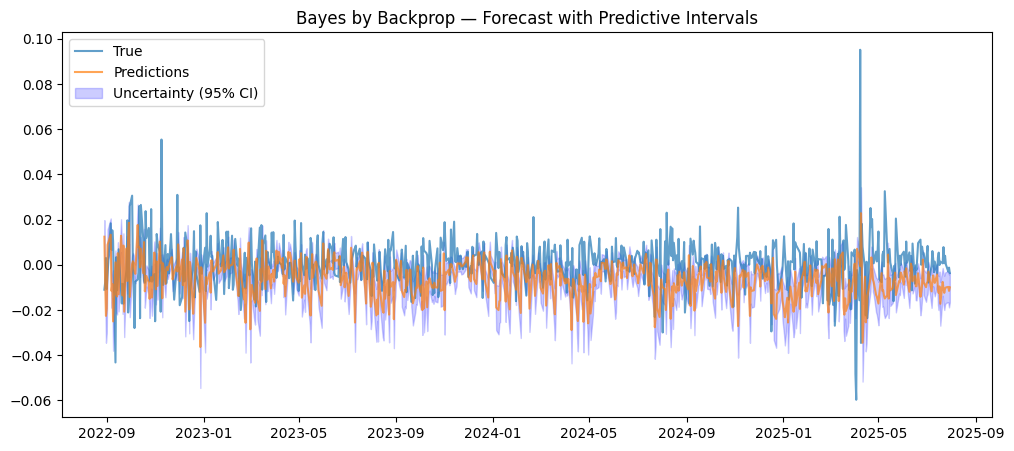

In [269]:
bbb_lower = bbb_mean_unscaled - 1.96 * bbb_std_unscaled
bbb_upper = bbb_mean_unscaled + 1.96 * bbb_std_unscaled

plt.figure(figsize=(12, 5))
plt.plot(idx_test, y_test, label="True", alpha=0.7)
plt.plot(idx_test, bbb_mean_unscaled, label="Predictions", alpha=0.7)
plt.fill_between(idx_test, bbb_lower, bbb_upper, alpha=0.2, label='Uncertainty (95% CI)', color='blue')
plt.title("Bayes by Backprop — Forecast with Predictive Intervals")
plt.legend()
plt.show()

In [270]:
# --- Split test into calibration + final (time-ordered) ---
n_test = len(y_test)
n_cal  = int(0.4 * n_test)

X_cal_tensor = X_test_tensor[:n_cal]
X_fin_tensor = X_test_tensor[n_cal:]
y_cal_real = np.asarray(y_test[:n_cal]).astype(float).ravel()
y_fin_real = np.asarray(y_test[n_cal:]).astype(float).ravel()

# Conformal (absolute residual quantile) on calibration & final
bbb_mu_cal, bbb_sd_cal, _ = predict_bbb(bbb_model, X_cal_tensor, device=device)
bbb_mu_fin, bbb_sd_fin, _ = predict_bbb(bbb_model, X_fin_tensor, device=device)

# Invert both mean & std to REAL scale
bbb_mu_cal_real = y_scaler.inverse_transform(np.array(bbb_mu_cal).reshape(-1,1)).ravel()
bbb_mu_fin_real = y_scaler.inverse_transform(np.array(bbb_mu_fin).reshape(-1,1)).ravel()

bbb_resid = np.abs(y_cal_real - bbb_mu_cal_real)
bbb_q = np.quantile(bbb_resid, 0.95)
bbb_lower_c = bbb_mu_fin_real - bbb_q
bbb_upper_c = bbb_mu_fin_real + bbb_q

bbb_picp_c = np.mean((y_fin_real >= bbb_lower_c) & (y_fin_real <= bbb_upper_c))
bbb_mpiw_c = np.mean(bbb_upper_c - bbb_lower_c)
print(f"Conformal MC — PICP: {bbb_picp_c:.6f} | MPIW: {bbb_mpiw_c:.6f}")

Conformal MC — PICP: 0.954545 | MPIW: 0.064134


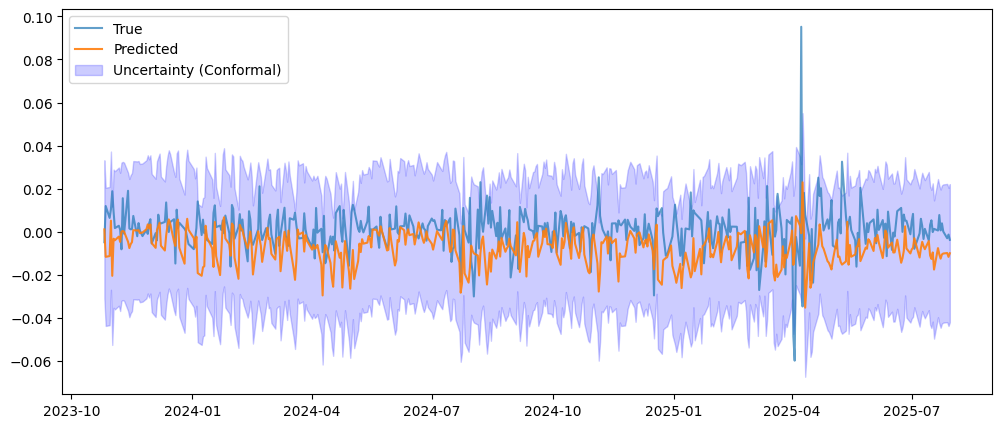

In [317]:
idx_fin = idx_test[n_cal:]

plt.figure(figsize=(12, 5))
plt.plot(idx_fin, y_test[n_cal:], label="True", alpha=0.7)
plt.plot(idx_fin, bbb_mu_fin_real, label="Predicted", alpha=0.9)
plt.fill_between(idx_fin, bbb_lower_c, bbb_upper_c, alpha=0.2, label='Uncertainty (Conformal)', color='blue')
plt.legend()
plt.savefig("forecast_con.png")
plt.show()

In [272]:
# Std rescales linearly by the same factor used for y standardisation
y_std = float(getattr(y_scaler, "scale_", [1.0])[0])
bbb_sd_cal_real = bbb_sd_cal * y_std
bbb_sd_fin_real = bbb_sd_fin * y_std

# --- Normalised residuals on calibration slice ---
eps = 1e-12
bbb_norm_resid = np.abs(y_cal_real - bbb_mu_cal_real) / (bbb_sd_cal_real + eps)

# Finite-sample conservative correction
alpha = 0.2
k = int(np.ceil((n_cal + 1) * (1 - alpha)))  # order statistic index
bbb_q_norm = np.sort(bbb_norm_resid)[min(k-1, len(bbb_norm_resid)-1)]  # guard bounds

# --- Adaptive (heteroscedastic) conformal intervals on final slice ---
bbb_lower_h = bbb_mu_fin_real - bbb_q_norm * bbb_sd_fin_real
bbb_upper_h = bbb_mu_fin_real + bbb_q_norm * bbb_sd_fin_real

bbb_picp_h = np.mean((y_fin_real >= bbb_lower_h) & (y_fin_real <= bbb_upper_h))
bbb_mpiw_h = np.mean(bbb_upper_h - bbb_lower_h)

print(f"Hybrid (normalised conformal) — PICP: {bbb_picp_h:.6f} | MPIW: {bbb_mpiw_h:.6f}")

Hybrid (normalised conformal) — PICP: 0.861364 | MPIW: 0.036307


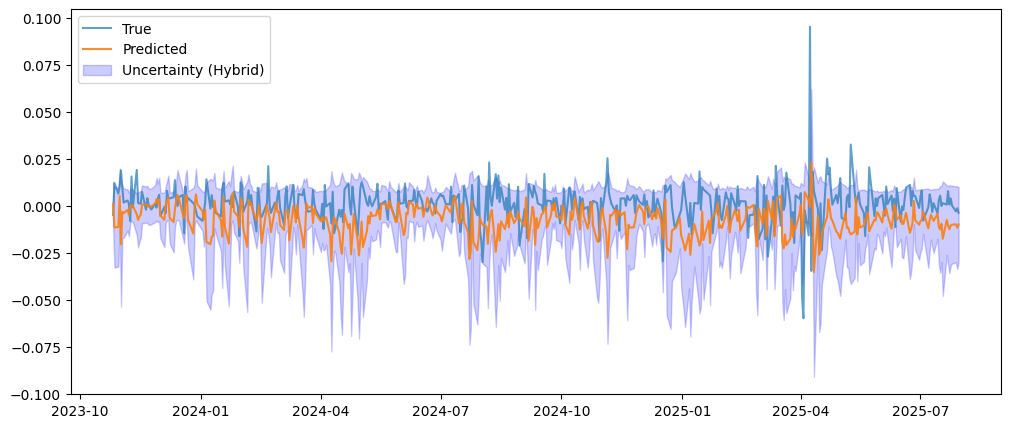

In [318]:
plt.figure(figsize=(12, 5))
plt.plot(idx_fin, y_test[n_cal:], label="True", alpha=0.7)
plt.plot(idx_fin, bbb_mu_fin_real, label="Predicted", alpha=0.9)
plt.fill_between(idx_fin, bbb_lower_h, bbb_upper_h, alpha=0.2, label='Uncertainty (Hybrid)', color='blue')
plt.legend()
plt.savefig("forecast_hyb.png")
plt.show()

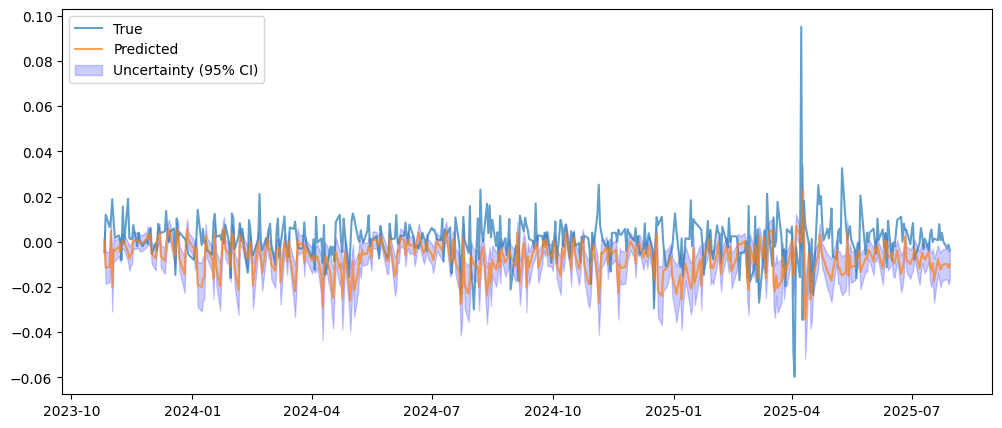

In [316]:
plt.figure(figsize=(12, 5))
plt.plot(idx_fin, y_test[n_cal:], label="True", alpha=0.7)
plt.plot(idx_fin, bbb_mean_unscaled[n_cal:], label="Predicted", alpha=0.7)
plt.fill_between(idx_fin, bbb_lower[n_cal:], bbb_upper[n_cal:], alpha=0.2, label='Uncertainty (95% CI)', color='blue')
plt.legend()
plt.savefig("forecast_raw.png")
plt.show()

## Gradient-Based Uncertainty Attribution (GUA)

In [277]:
def compute_feature_level_uncertainty_mc(model, test_loader, T=50):
    model.train()  # Enable dropout for MC Dropout
    feature_contributions = []

    for X_batch, _ in test_loader:
        X_batch = X_batch.clone().detach().requires_grad_(True)  # Track gradients

        preds = []
        for _ in range(T):
            y_pred = model(X_batch)  # (batch_size, 1)
            preds.append(y_pred)

        # (T, batch, 1) → variance: (batch, 1)
        preds_tensor = torch.stack(preds, dim=0)  # (T, B, 1)
        var_tensor = torch.var(preds_tensor, dim=0)  # (B, 1)

        # Backpropagate the uncertainty (sum of variances)
        var_tensor.sum().backward()

        # Get gradients: (batch, seq_len, num_features)
        grads = X_batch.grad.detach().cpu().numpy()

        # Aggregate gradient magnitudes per feature (over time steps)
        # Result: (batch, num_features)
        grads_per_feature = np.linalg.norm(grads, axis=1)
        feature_contributions.append(grads_per_feature)

    # (N, num_features)
    feature_contributions = np.vstack(feature_contributions)
    # (num_features,)
    mean_contributions = np.mean(feature_contributions, axis=0)
    return mean_contributions

In [278]:
mc_mean_attribution = compute_feature_level_uncertainty_mc(mc_model, test_loader, T=50)

In [307]:
# Sort by values (descending)
mc_sorted_indices = np.argsort(mc_mean_attribution)[::-1]
mc_sorted_values = mc_mean_attribution[mc_sorted_indices]
mc_sorted_labels = [feature_cols[i] for i in mc_sorted_indices]

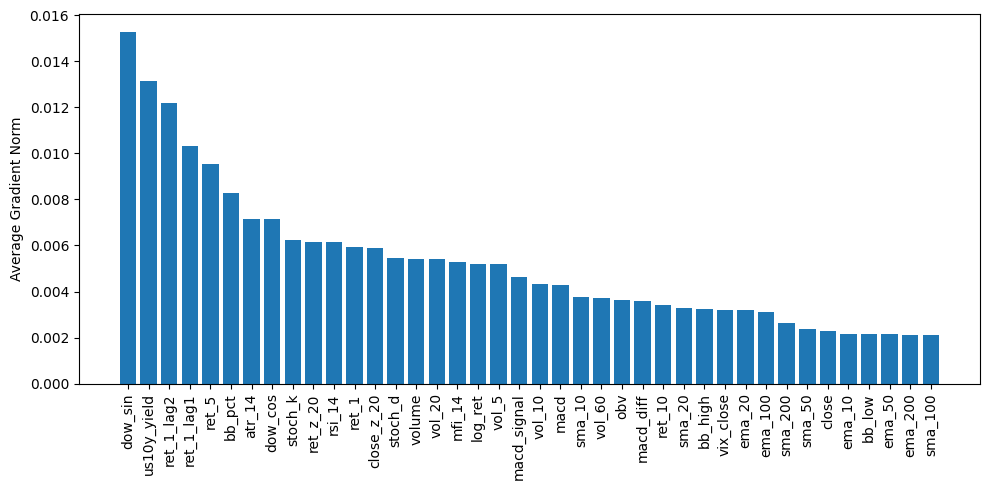

In [313]:
# Plot
plt.figure(figsize=(10, 5))
plt.bar(range(len(mc_sorted_labels)), mc_sorted_values)
plt.xticks(range(len(mc_sorted_labels)), mc_sorted_labels, rotation=90)
plt.ylabel("Average Gradient Norm")
plt.tight_layout()
plt.show()

In [280]:
def compute_feature_level_uncertainty_ensemble(members, test_loader, device="cpu"):
    feature_contributions = []

    for X_batch, _ in test_loader:
        X_batch = X_batch.clone().detach().requires_grad_(True).to(device)

        preds = []
        for model in members:
            model.eval()
            model.to(device)
            y_pred = model(X_batch)  # (batch_size, 1)
            preds.append(y_pred)

        # Stack ensemble predictions: (M, B, 1)
        preds_tensor = torch.stack(preds, dim=0)

        # Variance across ensemble members: (B, 1)
        var_tensor = torch.var(preds_tensor, dim=0)

        # Backprop through variance
        var_tensor.sum().backward()

        # Gradients: (B, seq_len, num_features)
        grads = X_batch.grad.detach().cpu().numpy()

        # Aggregate per feature (collapse over seq_len)
        grads_per_feature = np.linalg.norm(grads, axis=1)  # (B, num_features)
        feature_contributions.append(grads_per_feature)

    # Concatenate across batches → (N, num_features)
    feature_contributions = np.vstack(feature_contributions)

    # Average per feature
    mean_contributions = np.mean(feature_contributions, axis=0)

    return mean_contributions

In [282]:
ens_mean_attribution = compute_feature_level_uncertainty_ensemble(ensemble_models, test_loader)

In [309]:
# Sort by values (descending)
ens_sorted_indices = np.argsort(ens_mean_attribution)[::-1]
ens_sorted_values = ens_mean_attribution[ens_sorted_indices]
ens_sorted_labels = [feature_cols[i] for i in ens_sorted_indices]

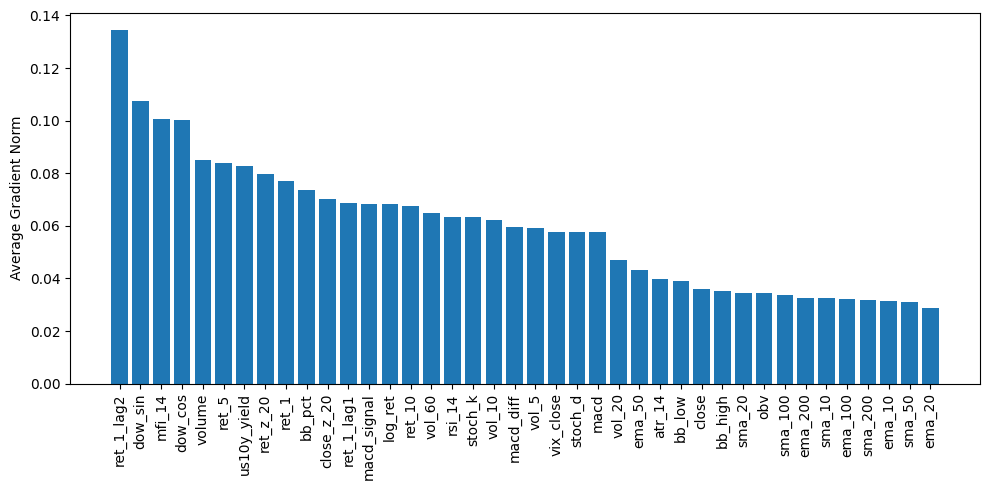

In [314]:
# Plot
plt.figure(figsize=(10, 5))
plt.bar(range(len(ens_sorted_labels)), ens_sorted_values)
plt.xticks(range(len(ens_sorted_labels)), ens_sorted_labels, rotation=90)
plt.ylabel("Average Gradient Norm")
plt.tight_layout()
plt.show()

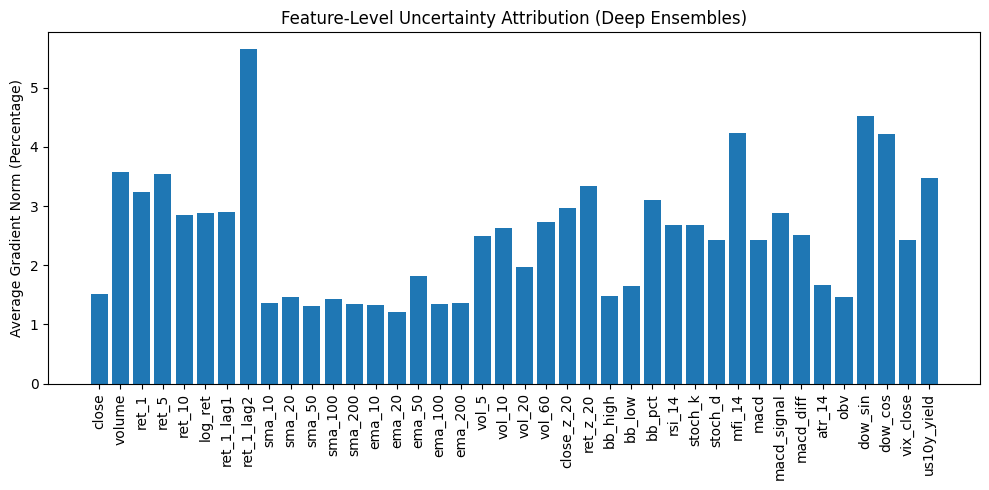

In [305]:
# Plot
plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_cols)), ens_att_perc)
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.ylabel("Average Gradient Norm (Percentage)")
plt.title("Feature-Level Uncertainty Attribution (Deep Ensembles)")
plt.tight_layout()
plt.show()

In [284]:
def compute_feature_level_uncertainty_bbb(model, test_loader, T=100, device="cpu"):
    model.to(device)
    feature_contributions = []

    for X_batch, _ in test_loader:
        # Make inputs require gradients
        X_batch = X_batch.clone().detach().to(device).requires_grad_(True)  # (B, L, F)

        # Collect T stochastic predictions
        preds = []
        for _ in range(T):
            # Important: do NOT use torch.no_grad(); we need autograd graph
            y_pred = model(X_batch)  # (B, 1); stochastic via BBB head
            preds.append(y_pred)

        # Stack across samples: (T, B, 1) -> variance over T: (B, 1)
        preds_tensor = torch.stack(preds, dim=0)          # (T, B, 1)
        var_tensor = torch.var(preds_tensor, dim=0)       # (B, 1)

        # Backpropagate sum of variances wrt inputs
        model.zero_grad(set_to_none=True)
        if X_batch.grad is not None:
            X_batch.grad.zero_()

        var_tensor.sum().backward()

        # Gradients wrt inputs: (B, L, F)
        grads = X_batch.grad.detach().cpu().numpy()

        # Aggregate over time steps (L) -> (B, F); use L2 or mean|.|; choose one and be consistent
        grads_per_feature = np.linalg.norm(grads, axis=1)   # L2 over time
        # Alternative: np.mean(np.abs(grads), axis=1)

        feature_contributions.append(grads_per_feature)

    # Concatenate batches: (N, F) and average to get global feature scores
    feature_contributions = np.vstack(feature_contributions)   # (N, F)
    mean_contributions = np.mean(np.abs(feature_contributions), axis=0)  # (F,)
    
    return mean_contributions

In [285]:
bbb_feature_importance = compute_feature_level_uncertainty_bbb(bbb_model, test_loader, T=100, device=device)

In [311]:
# Sort by values (descending)
bbb_sorted_indices = np.argsort(bbb_feature_importance)[::-1]
bbb_sorted_values = bbb_feature_importance[bbb_sorted_indices]
bbb_sorted_labels = [feature_cols[i] for i in bbb_sorted_indices]

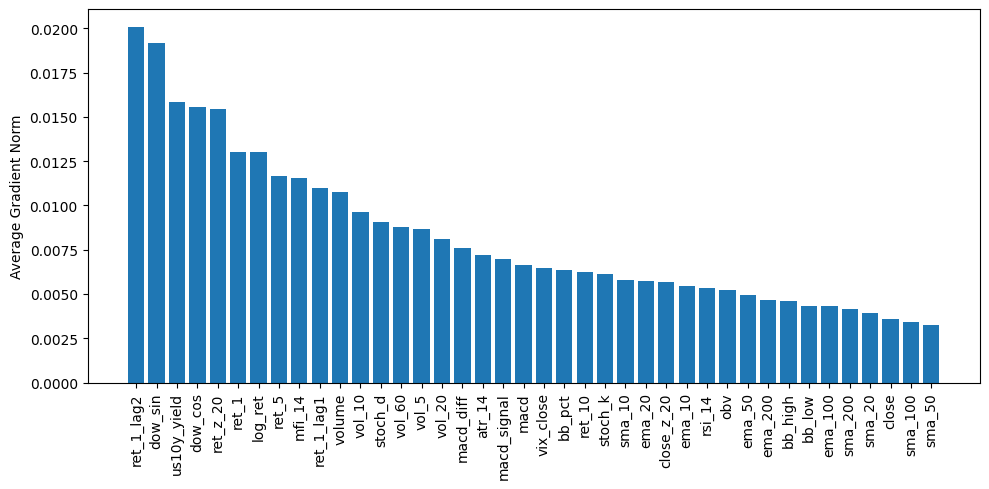

In [315]:
# Plot
plt.figure(figsize=(10, 5))
plt.bar(range(len(bbb_sorted_labels)), bbb_sorted_values)
plt.xticks(range(len(bbb_sorted_labels)), bbb_sorted_labels, rotation=90)
plt.ylabel("Average Gradient Norm")
plt.tight_layout()
plt.show()